<a href="https://colab.research.google.com/github/Hawlll/Hancoded_MLAlgos/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression

Logistic regression is a supervised machine learning algoritim used for binary classification. The model minimizes the log loss/binary crossentropy function, and the model outputs probabilties.

minimize => (-1/N) x sum(yi*ln(y_hat) + (1-yi)*ln(1-yhat))

In [654]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

In [655]:
X, y = load_breast_cancer(return_X_y=True)

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

print("X train shape: ",x_train.shape)
print("X test shape: ",x_test.shape)

print("y train shape: ",y_train.shape)
print("y train shape: ",y_test.shape)



X train shape:  (455, 30)
X test shape:  (114, 30)
y train shape:  (455, 1)
y train shape:  (114, 1)


In [656]:
x_train[0:5, :]

array([[-0.64962332, -0.08136555, -0.67795088, -0.64529589, -0.54443564,
        -0.66976393, -0.77978067, -0.90250941, -1.01722084, -0.31578688,
        -0.66038458, -0.63802025, -0.70396285, -0.51081543, -0.50801357,
        -0.4587491 , -0.37943957, -0.81901884, -0.53060218, -0.33017706,
        -0.61486734, -0.11191003, -0.656516  , -0.58764056, -0.19150121,
        -0.42153826, -0.60011494, -0.69244814, -0.5917125 , -0.22253979],
       [ 0.60855956,  0.33052533,  0.6150095 ,  0.45167449,  1.46171817,
         0.52228412,  0.74075188,  0.92757364,  0.49792067, -0.00391398,
         0.11667834,  0.02748109,  0.19996305,  0.08961122, -0.11466429,
        -0.25978234,  0.01943942,  0.34451109, -0.62746498, -0.38048449,
         0.62348619,  0.765818  ,  0.67133668,  0.42263187,  1.16741142,
         0.25722281,  0.41983856,  0.66530755,  0.32718689, -0.10782905],
       [ 0.28478338,  2.44815641,  0.19528136,  0.18376002, -0.93655723,
        -1.10470039, -0.5265469 , -0.55532241,  0

In [657]:
y_train[0:5]

array([[1],
       [0],
       [0],
       [1],
       [0]])

In [658]:
class LogisticRegression:

  def __init__(self, lr, epochs=10, thresh=0.7):

    self.lr = lr
    self.epochs = epochs
    self.thresh = thresh

    self.W = None
    self.b = None

  def sigmoid(self, z):

    return 1 / (1 + np.exp(-z))

  def fit(self, X, y):

    self.W = np.random.randn(X.shape[1], 1)
    self.b = np.ones((1, 1))

    train_loss, train_acc = [], []

    for epoch in range(self.epochs):

      z = (X @ self.W) + self.b
      y_hat = self.sigmoid(z)

      grad_W = (1/X.shape[0]) * X.T @ (y_hat - y)
      grad_b = (1/X.shape[0]) * np.sum(y_hat - y)

      self.W -= self.lr * grad_W
      self.b -= self.lr * grad_b

      train_yhat = self.predict_proba(x_train) + 1e-15
      probs_clipped = np.clip(train_yhat, 1e-15, 1-1e-15)
      loss = (-1/X.shape[0]) * np.sum((y * np.log(probs_clipped)) + ((1-y) * np.log(1-probs_clipped)))
      acc = np.mean(self.predict(x_train).reshape(-1, 1) == y_train)

      train_loss.append(loss)
      train_acc.append(acc)

    return train_loss, train_acc

  def predict(self, X):

    z = (X @ self.W) + self.b

    y_hat = self.sigmoid(z)

    return (y_hat > self.thresh).astype(int)

  def predict_proba(self, X):

    z = (X @ self.W) + self.b

    return self.sigmoid(z)

Test Accuracy:  0.8070175438596491


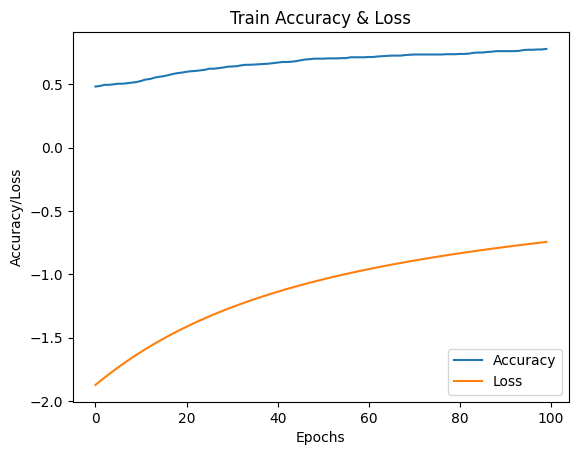

In [659]:
log = LogisticRegression(0.01, 100, 0.5)
train_loss, train_acc = log.fit(x_train, y_train)

train_loss = -np.array(train_loss)
train_acc = np.array(train_acc)

pred_probs = log.predict_proba(x_test)
pred_class = log.predict(x_test)

print("Test Accuracy: ", np.mean(pred_class == y_test))

plt.title("Train Accuracy & Loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Loss")
plt.plot(train_acc, label="Accuracy")
plt.plot(train_loss, label="Loss")
plt.legend()
plt.show()

In [660]:
feat_coeffs_odds = pd.DataFrame(np.concatenate([log.W, np.exp(log.W)], axis=1), columns=["Coefficient", "Odds_Ratio"])
feat_coeffs_odds.index = ["X"+str(i) for i in range(1, X.shape[1]+1)]
print(f"Bias Coeff: {log.b[0]}, Bias Odds Ratio: {np.exp(log.b)[0]}")
feat_coeffs_odds

Bias Coeff: [0.95097452], Bias Odds Ratio: [2.5882307]


,Coefficient,Odds_Ratio
X1,-0.443460,0.641812
X2,0.601585,1.825010
X3,0.644755,1.905520
X4,-0.136848,0.872103
X5,-0.836835,0.433079
X6,0.070790,1.073356
X7,-2.029662,0.131380
X8,0.235926,1.266080
X9,-0.109013,0.896719
X10,0.452454,1.572166
